# CDS 2413 — Introduction to Data Science
## Deliverable 1: Data Analysis Report — Jupyter Notebook
### Dataset: Medical Insurance Cost Prediction
**Source:** [Kaggle — Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)

---

## 1. Setup & Imports

In [1]:
# Mayed - Updated imports and display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Load & Inspect Dataset

In [2]:
# Load the dataset
# Make sure insurance.csv is in the same directory as this notebook
df = pd.read_csv('insurance.csv')

print(f"Shape: {df.shape[0]} records × {df.shape[1]} columns")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(10)

Shape: 1338 records × 7 columns

Column types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,"16,884.92"
1,18,male,33.77,1,no,southeast,"1,725.55"
2,28,male,33.00,3,no,southeast,"4,449.46"
3,33,male,22.70,0,no,northwest,"21,984.47"
4,32,male,28.88,0,no,northwest,"3,866.86"
5,31,female,25.74,0,no,southeast,"3,756.62"
6,46,female,33.44,1,no,southeast,"8,240.59"
7,37,female,27.74,3,no,northwest,"7,281.51"
8,37,male,29.83,2,no,northeast,"6,406.41"
9,60,female,25.84,0,no,northwest,"28,923.14"


In [3]:
# Quick statistical overview of the dataset
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,"1,338.00",1338,"1,338.00","1,338.00",1338,1338,"1,338.00"
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.21,NaN,30.66,1.09,NaN,NaN,"13,270.42"
std,14.05,NaN,6.10,1.21,NaN,NaN,"12,110.01"
min,18.00,NaN,15.96,0.00,NaN,NaN,"1,121.87"
25%,27.00,NaN,26.30,0.00,NaN,NaN,"4,740.29"
50%,39.00,NaN,30.40,1.00,NaN,NaN,"9,382.03"
75%,51.00,NaN,34.69,2.00,NaN,NaN,"16,639.91"


---
## CLO2: Descriptive, Exploratory and Statistical Analysis

### 3. Descriptive Statistics Function
A reusable Python function that takes any DataFrame sample and a field name, then computes the full descriptive statistics.

In [4]:
def descriptive_statistics(sample, field):
    """
    Compute and display descriptive statistics for a given field in a sample.
    
    Parameters:
        sample (pd.DataFrame): The data sample
        field (str): Column name to analyse
    """
    data = sample[field]
    
    count = data.count()
    mean = data.mean()
    median = data.median()
    mode = data.mode()[0]
    std = data.std()
    var = data.var()
    minimum = data.min()
    maximum = data.max()
    data_range = maximum - minimum
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    skewness = data.skew()
    kurtosis = data.kurtosis()
    
    stats_dict = {
        'Count': f'{count}',
        'Mean': f'${mean:,.2f}',
        'Median': f'${median:,.2f}',
        'Mode': f'${mode:,.2f}',
        'Std Deviation': f'${std:,.2f}',
        'Variance': f'{var:,.2f}',
        'Minimum': f'${minimum:,.2f}',
        'Maximum': f'${maximum:,.2f}',
        'Range': f'${data_range:,.2f}',
        'Q1 (25th %ile)': f'${q1:,.2f}',
        'Q3 (75th %ile)': f'${q3:,.2f}',
        'IQR': f'${iqr:,.2f}',
        'Skewness': f'{skewness:.3f}',
        'Kurtosis': f'{kurtosis:.3f}'
    }
    
    stats_df = pd.DataFrame(list(stats_dict.items()), columns=['Statistic', 'Value'])
    print(f"\n{'='*50}")
    print(f"  Descriptive Statistics: {field}")
    print(f"  Sample Size: {count}")
    print(f"{'='*50}")
    print(stats_df.to_string(index=False))
    print(f"{'='*50}\n")
    
    return stats_dict

# Test the function on the full dataset
print("Function defined successfully. Testing on full dataset:")
_ = descriptive_statistics(df, 'charges')

Function defined successfully. Testing on full dataset:

  Descriptive Statistics: charges
  Sample Size: 1338
     Statistic          Value
         Count           1338
          Mean     $13,270.42
        Median      $9,382.03
          Mode      $1,639.56
 Std Deviation     $12,110.01
      Variance 146,652,372.15
       Minimum      $1,121.87
       Maximum     $63,770.43
         Range     $62,648.55
Q1 (25th %ile)      $4,740.29
Q3 (75th %ile)     $16,639.91
           IQR     $11,899.63
      Skewness          1.516
      Kurtosis          1.606



### 4. Random Sampling (n = 150)
Simple random sample using `pandas.sample()` with `random_state=42` for reproducibility. Every record has an equal probability of selection.

In [5]:
# Random Sampling — n = 150, seed = 42
random_sample = df.sample(n=150, random_state=42)

print(f"Random sample shape: {random_sample.shape}")
print(f"\nDescriptive statistics for 'charges' — Random Sample:\n")
random_stats = descriptive_statistics(random_sample, 'charges')

Random sample shape: (150, 7)

Descriptive statistics for 'charges' — Random Sample:


  Descriptive Statistics: charges
  Sample Size: 150
     Statistic          Value
         Count            150
          Mean     $13,010.72
        Median      $8,702.95
          Mode      $1,131.51
 Std Deviation     $11,916.85
      Variance 142,011,405.59
       Minimum      $1,131.51
       Maximum     $48,673.56
         Range     $47,542.05
Q1 (25th %ile)      $4,727.57
Q3 (75th %ile)     $18,179.94
           IQR     $13,452.37
      Skewness          1.371
      Kurtosis          0.930



### 5. Systematic Sampling (n = 150)
Interval k = ⌊1338 / 150⌋ = 8. Random start position between 0 and k−1 (using seed=42), then every k-th row is selected.

In [6]:
# Systematic Sampling
N = len(df)           # 1338
n = 150               # target sample size
k = N // n            # interval = 8

np.random.seed(42)
start = np.random.randint(0, k)  # random start between 0 and 7
print(f"Population size (N): {N}")
print(f"Sample size (n): {n}")
print(f"Sampling interval (k): {k}")
print(f"Random start position: {start}")

# Select every k-th record from the start
indices = list(range(start, N, k))[:n]
systematic_sample = df.iloc[indices]

print(f"Systematic sample shape: {systematic_sample.shape}")
print(f"\nDescriptive statistics for 'charges' — Systematic Sample:\n")
systematic_stats = descriptive_statistics(systematic_sample, 'charges')

Population size (N): 1338
Sample size (n): 150
Sampling interval (k): 8
Random start position: 6
Systematic sample shape: (150, 7)

Descriptive statistics for 'charges' — Systematic Sample:


  Descriptive Statistics: charges
  Sample Size: 150
     Statistic          Value
         Count            150
          Mean     $13,250.87
        Median     $10,150.24
          Mode      $1,137.01
 Std Deviation     $11,541.04
      Variance 133,195,637.53
       Minimum      $1,137.01
       Maximum     $48,970.25
         Range     $47,833.24
Q1 (25th %ile)      $4,909.49
Q3 (75th %ile)     $16,955.25
           IQR     $12,045.76
      Skewness          1.424
      Kurtosis          1.253



### 6. Descriptive Statistics Report — Full Dataset
Running the same function on all 1,338 records for population-level reference.

In [7]:
# Full dataset descriptive statistics
print("Descriptive statistics for 'charges' — Full Dataset (Population):\n")
population_stats = descriptive_statistics(df, 'charges')

Descriptive statistics for 'charges' — Full Dataset (Population):


  Descriptive Statistics: charges
  Sample Size: 1338
     Statistic          Value
         Count           1338
          Mean     $13,270.42
        Median      $9,382.03
          Mode      $1,639.56
 Std Deviation     $12,110.01
      Variance 146,652,372.15
       Minimum      $1,121.87
       Maximum     $63,770.43
         Range     $62,648.55
Q1 (25th %ile)      $4,740.29
Q3 (75th %ile)     $16,639.91
           IQR     $11,899.63
      Skewness          1.516
      Kurtosis          1.606



### Sampling Comparison Summary

In [8]:
# Compare the three: Population vs Random vs Systematic
comparison = pd.DataFrame({
    'Statistic': list(population_stats.keys()),
    'Population (N=1338)': list(population_stats.values()),
    'Random Sample (n=150)': list(random_stats.values()),
    'Systematic Sample (n=150)': list(systematic_stats.values())
})
comparison

,Statistic,Population (N=1338),Random Sample (n=150),Systematic Sample (n=150)
0,Count,1338,150,150
1,Mean,"$13,270.42","$13,010.72","$13,250.87"
2,Median,"$9,382.03","$8,702.95","$10,150.24"
3,Mode,"$1,639.56","$1,131.51","$1,137.01"
4,Std Deviation,"$12,110.01","$11,916.85","$11,541.04"
5,Variance,"146,652,372.15","142,011,405.59","133,195,637.53"
6,Minimum,"$1,121.87","$1,131.51","$1,137.01"
7,Maximum,"$63,770.43","$48,673.56","$48,970.25"
8,Range,"$62,648.55","$47,542.05","$47,833.24"
9,Q1 (25th %ile),"$4,740.29","$4,727.57","$4,909.49"


---
### 7. Visualisation — Scatter Plot
Insurance charges vs age, colour-coded by smoking status.

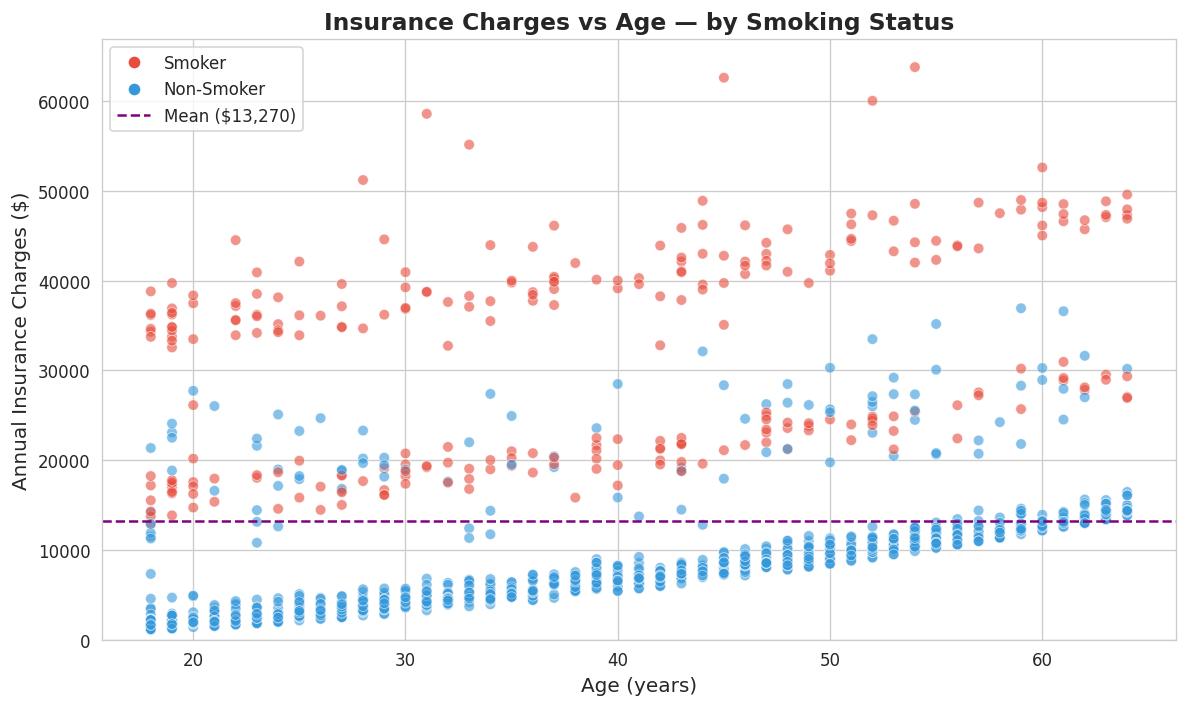

In [9]:
# Scatter Plot: Age vs Charges, coloured by Smoker status
fig, ax = plt.subplots(figsize=(10, 6))

colors = df['smoker'].map({'yes': '#e74c3c', 'no': '#3498db'})
ax.scatter(df['age'], df['charges'], c=colors, alpha=0.6, edgecolors='w', linewidth=0.5, s=40)

# Mean line
mean_charges = df['charges'].mean()
ax.axhline(y=mean_charges, color='purple', linestyle='--', linewidth=1.5, 
           label=f'Mean Charges (${mean_charges:,.0f})')

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Annual Insurance Charges ($)', fontsize=12)
ax.set_title('Insurance Charges vs Age — by Smoking Status', fontsize=14, fontweight='bold')

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='Smoker'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='Non-Smoker'),
    Line2D([0], [0], color='purple', linestyle='--', linewidth=1.5, label=f'Mean (${mean_charges:,.0f})')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

### 8. Visualisation — Box Plot
Distribution of charges across the full dataset, showing median, IQR, and outliers.

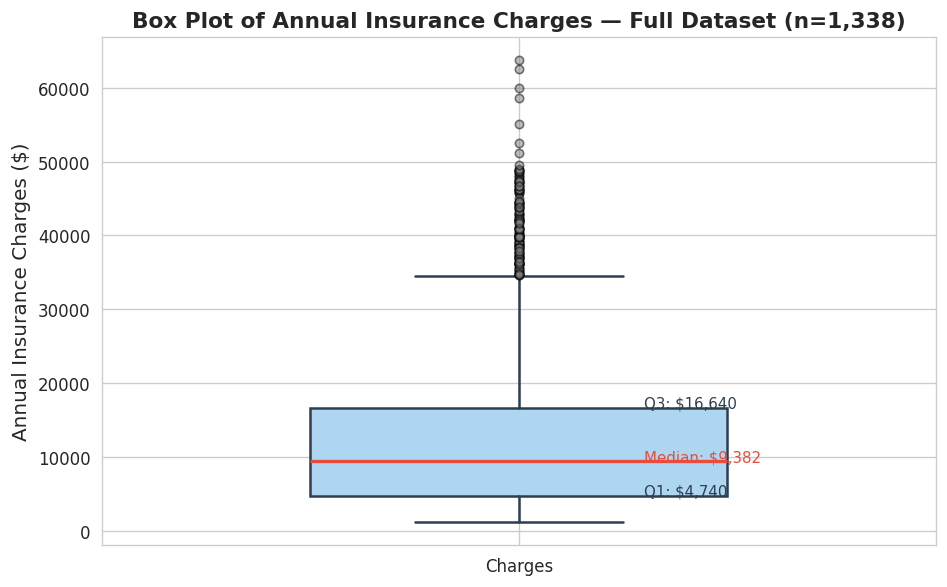

In [10]:
# Box Plot: Charges distribution
fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot(df['charges'], vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor='#AED6F1', edgecolor='#2C3E50', linewidth=1.5),
                medianprops=dict(color='#E74C3C', linewidth=2),
                whiskerprops=dict(color='#2C3E50', linewidth=1.5),
                capprops=dict(color='#2C3E50', linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor='grey', markersize=5, alpha=0.5))

ax.set_ylabel('Annual Insurance Charges ($)', fontsize=12)
ax.set_title('Box Plot of Annual Insurance Charges — Full Dataset (n=1,338)', fontsize=13, fontweight='bold')
ax.set_xticklabels(['Charges'])

# Annotate key statistics
median_val = df['charges'].median()
q1 = df['charges'].quantile(0.25)
q3 = df['charges'].quantile(0.75)
ax.annotate(f'Median: ${median_val:,.0f}', xy=(1.15, median_val), fontsize=9, color='#E74C3C')
ax.annotate(f'Q1: ${q1:,.0f}', xy=(1.15, q1), fontsize=9, color='#2C3E50')
ax.annotate(f'Q3: ${q3:,.0f}', xy=(1.15, q3), fontsize=9, color='#2C3E50')

plt.tight_layout()
plt.show()

### 9. Visualisation — Histogram
Frequency distribution of charges with mean and median reference lines.

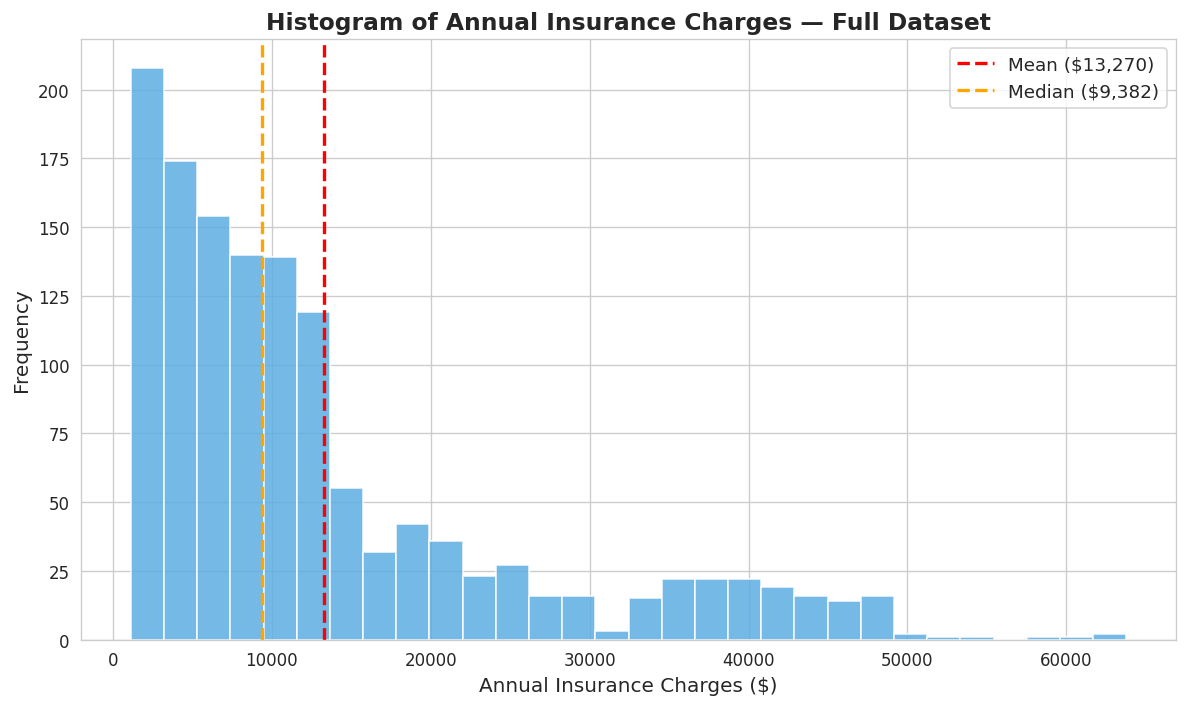

In [11]:
# Histogram: Charges distribution
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df['charges'], bins=30, color='#5DADE2', edgecolor='white', alpha=0.85)

mean_val = df['charges'].mean()
median_val = df['charges'].median()

ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean (${mean_val:,.0f})')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median (${median_val:,.0f})')

ax.set_xlabel('Annual Insurance Charges ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Histogram of Annual Insurance Charges — Full Dataset', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 10. Visualisation — Correlation Heat Map
Pearson correlation matrix for numerical variables: age, bmi, children, charges.

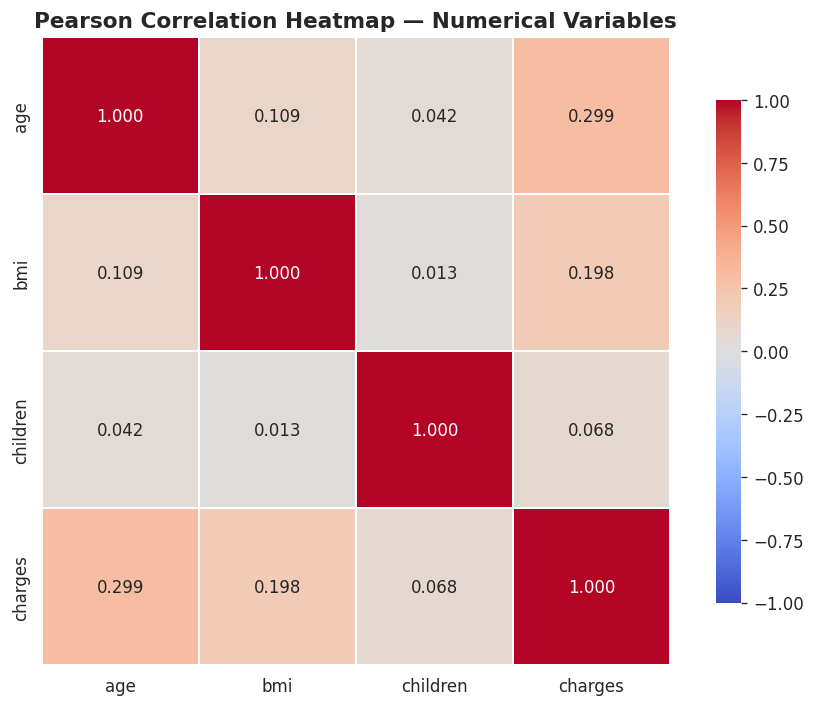

In [12]:
# Correlation Heatmap
numerical_cols = ['age', 'bmi', 'children', 'charges']
corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, linecolor='white',
            cbar_kws={'shrink': 0.8}, ax=ax,
            vmin=-1, vmax=1)

ax.set_title('Pearson Correlation Heatmap — Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 11. Hypothesis Testing

Three tests at α = 0.05:
1. **Pearson** — charges vs age (numerical, linear)
2. **Spearman** — charges vs BMI (numerical, monotonic / robust to skew)
3. **Chi-Square** — smoker status vs charge category (categorical)

In [13]:
# ─── Pearson Correlation: charges vs age ───
pearson_r, pearson_p = stats.pearsonr(df['age'], df['charges'])

print("=" * 55)
print("  PEARSON CORRELATION TEST — Charges vs Age")
print("=" * 55)
print(f"  H₀: No linear correlation (r = 0)")
print(f"  H₁: Significant linear correlation (r ≠ 0)")
print(f"  α  = 0.05")
print("-" * 55)
print(f"  Pearson r  = {pearson_r:.4f}")
print(f"  P-value    = {pearson_p:.6f}")
print(f"  Decision   = {'Reject H₀' if pearson_p < 0.05 else 'Fail to reject H₀'}")
print("=" * 55)

  PEARSON CORRELATION TEST — Charges vs Age
  H₀: No linear correlation (r = 0)
  H₁: Significant linear correlation (r ≠ 0)
  α  = 0.05
-------------------------------------------------------
  Pearson r  = 0.2990
  P-value    = 0.000000
  Decision   = Reject H₀


In [14]:
# ─── Spearman Correlation: charges vs BMI ───
spearman_rho, spearman_p = stats.spearmanr(df['bmi'], df['charges'])

print("=" * 55)
print("  SPEARMAN CORRELATION TEST — Charges vs BMI")
print("=" * 55)
print(f"  H₀: No monotonic correlation (ρ = 0)")
print(f"  H₁: Significant monotonic correlation (ρ ≠ 0)")
print(f"  α  = 0.05")
print("-" * 55)
print(f"  Spearman ρ = {spearman_rho:.4f}")
print(f"  P-value    = {spearman_p:.6f}")
print(f"  Decision   = {'Reject H₀' if spearman_p < 0.05 else 'Fail to reject H₀'}")
print("=" * 55)

  SPEARMAN CORRELATION TEST — Charges vs BMI
  H₀: No monotonic correlation (ρ = 0)
  H₁: Significant monotonic correlation (ρ ≠ 0)
  α  = 0.05
-------------------------------------------------------
  Spearman ρ = 0.1194
  P-value    = 0.000012
  Decision   = Reject H₀


In [15]:
# ─── Chi-Square Test: Smoker status vs Charge category ───

# Bin charges into Low / Medium / High
df['charge_category'] = pd.cut(df['charges'], bins=3, labels=['Low', 'Medium', 'High'])

# Contingency table
contingency = pd.crosstab(df['smoker'], df['charge_category'])
print("Contingency Table:")
print(contingency)
print()

# Chi-square test
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)

print("=" * 55)
print("  CHI-SQUARE TEST — Smoker Status vs Charge Category")
print("=" * 55)
print(f"  H₀: Smoking status and charge category are independent")
print(f"  H₁: Smoking status and charge category are associated")
print(f"  α  = 0.05")
print("-" * 55)
print(f"  Chi-Square (χ²)    = {chi2:.2f}")
print(f"  P-value            = {chi_p:.6f}")
print(f"  Degrees of Freedom = {dof}")
print(f"  Decision           = {'Reject H₀' if chi_p < 0.05 else 'Fail to reject H₀'}")
print("=" * 55)

# Clean up the temporary column
df.drop('charge_category', axis=1, inplace=True)

Contingency Table:
charge_category   Low  Medium  High
smoker                             
no               1016      48     0
yes                83     137    54

  CHI-SQUARE TEST — Smoker Status vs Charge Category
  H₀: Smoking status and charge category are independent
  H₁: Smoking status and charge category are associated
  α  = 0.05
-------------------------------------------------------
  Chi-Square (χ²)    = 648.53
  P-value            = 0.000000
  Degrees of Freedom = 2
  Decision           = Reject H₀


---
### 12. One-Sample T-Test
Assess whether the random sample mean is statistically different from the population mean. This determines if the sample is representative of the population.

In [16]:
# One-Sample T-Test: Random sample mean vs Population mean
population_mean = df['charges'].mean()
sample_mean = random_sample['charges'].mean()

t_stat, t_pvalue = stats.ttest_1samp(random_sample['charges'], population_mean)

print("=" * 60)
print("  ONE-SAMPLE T-TEST — Random Sample vs Population")
print("=" * 60)
print(f"  H₀: μ_sample = μ_population = ${population_mean:,.2f}")
print(f"  H₁: μ_sample ≠ μ_population")
print(f"  α  = 0.05  |  Two-tailed")
print("-" * 60)
print(f"  Population Mean (μ)   = ${population_mean:,.2f}")
print(f"  Sample Mean (x̄)       = ${sample_mean:,.2f}")
print(f"  Difference            = ${abs(population_mean - sample_mean):,.2f}  ({abs(population_mean - sample_mean)/population_mean*100:.2f}%)")
print(f"  T-Statistic           = {t_stat:.4f}")
print(f"  P-Value               = {t_pvalue:.4f}")
print(f"  Degrees of Freedom    = {len(random_sample) - 1}")
print("-" * 60)
if t_pvalue > 0.05:
    print(f"  Decision:  FAIL TO REJECT H₀ (p = {t_pvalue:.4f} > α = 0.05)")
    print(f"  Conclusion: The random sample IS representative of the population.")
else:
    print(f"  Decision:  REJECT H₀ (p = {t_pvalue:.4f} < α = 0.05)")
    print(f"  Conclusion: The sample mean differs significantly from the population.")
print("=" * 60)

  ONE-SAMPLE T-TEST — Random Sample vs Population
  H₀: μ_sample = μ_population = $13,270.42
  H₁: μ_sample ≠ μ_population
  α  = 0.05  |  Two-tailed
------------------------------------------------------------
  Population Mean (μ)   = $13,270.42
  Sample Mean (x̄)       = $13,010.72
  Difference            = $259.71  (1.96%)
  T-Statistic           = -0.2669
  P-Value               = 0.7899
  Degrees of Freedom    = 149
------------------------------------------------------------
  Decision:  FAIL TO REJECT H₀ (p = 0.7899 > α = 0.05)
  Conclusion: The random sample IS representative of the population.


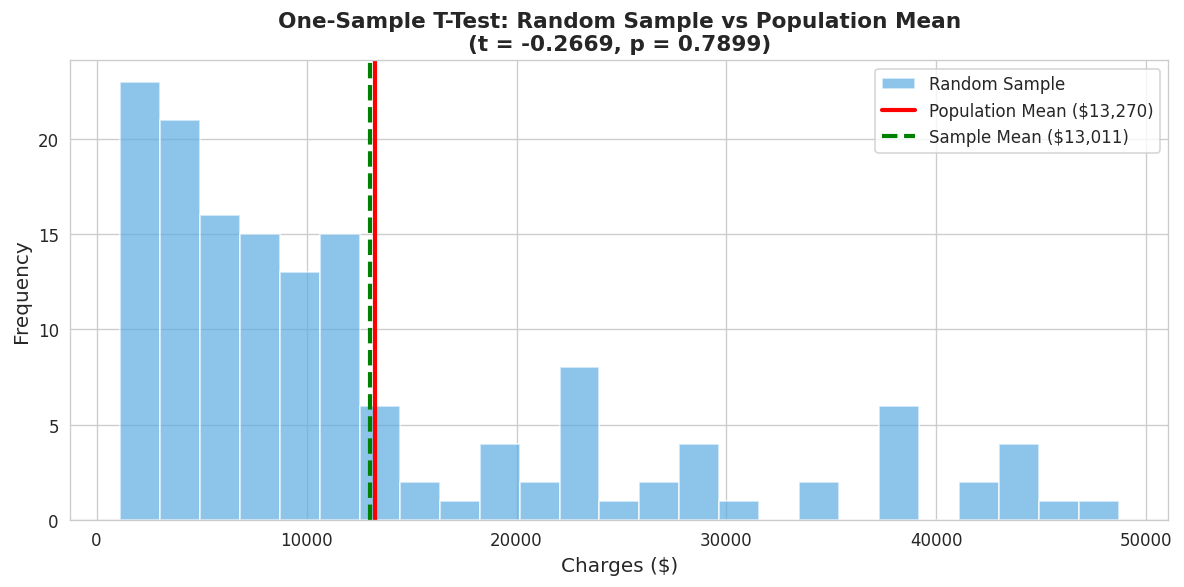

In [17]:
# Visualise the t-test result
fig, ax = plt.subplots(figsize=(10, 5))

# Plot sample distribution
ax.hist(random_sample['charges'], bins=25, color='#5DADE2', edgecolor='white', alpha=0.7, label='Random Sample')

# Reference lines
ax.axvline(population_mean, color='red', linestyle='-', linewidth=2.5, label=f'Population Mean (${population_mean:,.0f})')
ax.axvline(sample_mean, color='green', linestyle='--', linewidth=2.5, label=f'Sample Mean (${sample_mean:,.0f})')

ax.set_xlabel('Charges ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'One-Sample T-Test: Random Sample vs Population Mean\n(t = {t_stat:.4f}, p = {t_pvalue:.4f})', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## References

- Choi, M. (2018). Medical Cost Personal Dataset. Kaggle. https://www.kaggle.com/datasets/mirichoi0218/insurance
- Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585(7825), 357–362.
- Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95.
- McKinney, W. (2022). pandas: Powerful Python data analysis toolkit. https://pandas.pydata.org/
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *JMLR*, 12, 2825–2830.
- Virtanen, P., et al. (2020). SciPy 1.0. *Nature Methods*, 17, 261–272.
- Waskom, M. L. (2021). Seaborn: Statistical data visualization. *JOSS*, 6(60), 3021.